# Parse Summarized Activities Notebook
\
This is the first exploration of the Garmin Data. In this notebook, I unpack the Summarized Activities file. The data is originally contained in a JSON file which is loaded into a pandas DataFrame.\
The file includes the following activities (with corresponding counts):
- running               856
- strength_training      35
- treadmill_running      35
- walking                13
- stop_watch              6
- indoor_cycling          3
- cycling                 3
- track_running           3
- mixed_martial_arts      1
- hiking                  1
- indoor_running          1

#### Load in Summarized Activites Data

In [ ]:
# Necessary imports
import pandas as pd 
import numpy as np
import json
from pathlib import Path

In [ ]:
# Path to the JSON file containing the summarized activities data
path = Path.cwd() / "data_raw/athlete_001/DI_CONNECT/DI-Connect-Fitness/pabloherreramendez@gmail.com_0_summarizedActivities.json"

# Load the JSON data from the file
with open(path, "r") as f:
    data = json.load(f)

type(data)

list

In [3]:
# The data is a list contianing of a single dictionary with the key 'summarizedActivitiesExport' which contains the activities data
activities = data[0]['summarizedActivitiesExport']
len(activities)

957

In [4]:
# Convert the list of ativities to a pandas DataFrame
df = pd.json_normalize(activities)

# Display some features of the DataFrame
print(df.shape)
print(df.head())
print(df.columns.tolist())

(957, 109)
    activityId              uuidMsb              uuidLsb               name  \
0  22798253681 -1435159994000456239 -7476692020567272721    Medford Running   
1  22754442788 -5173427863551655927 -6056680477417831440    Medford Running   
2  22731170149   228799000066278220 -6043738082960910409    Medford Running   
3  22705328725  4937610586496847375 -5923432035453367446  Lexington Running   
4  22694821579   931121816221204921 -6809928238247391998     Indoor Cycling   

     activityType  userProfileId  timeZoneId  beginTimestamp  eventTypeId  \
0         running       48001360         149   1778166672000            9   
1         running       48001360         149   1777835304000            9   
2         running       48001360         149   1777672763000            9   
3         running       48001360         149   1777483501000            9   
4  indoor_cycling       48001360         149   1777407034000            9   

          rule  ... activeSets  totalSets  totalRep

In [5]:
# Display the count of each activity type
print(df['activityType'].value_counts())

activityType
running               856
strength_training      35
treadmill_running      35
walking                13
stop_watch              6
indoor_cycling          3
cycling                 3
track_running           3
mixed_martial_arts      1
hiking                  1
indoor_running          1
Name: count, dtype: int64


In [6]:
# Covert the start time from milliseconds to datetime format
df["start_time"] = pd.to_datetime(df["startTimeLocal"], unit='ms')
print(df["start_time"].head())

0   2026-05-07 11:11:12
1   2026-05-03 15:08:24
2   2026-05-01 17:59:23
3   2026-04-29 13:25:01
4   2026-04-28 16:10:34
Name: start_time, dtype: datetime64[ns]


In [7]:
# Explore the earliest and latest activity dates
print(df["start_time"].min())
print(df["start_time"].max())

2016-11-13 09:16:19
2026-05-07 11:11:12


In [8]:
# Convert the duration from milliseconds to minutes
print(df["duration"].head())
df["duration_minutes"] = df["duration"] / 1000 / 60
print(df["duration_minutes"].head())

0    1.996792e+06
1    3.464776e+06
2    2.081378e+06
3    1.945939e+06
4    2.700123e+06
Name: duration, dtype: float64
0    33.279867
1    57.746265
2    34.689632
3    32.432316
4    45.002051
Name: duration_minutes, dtype: float64


In [ ]:
# PCT hiking day with my friend!!
print(df["duration_minutes"].max())
pct = df.loc[df['duration_minutes'] == df['duration_minutes'].max()]
print(pct[["activityType", "duration_minutes"]])
print(pct["start_time"])

397.56520182291666
    activityType  duration_minutes
512      walking        397.565202
512   2024-05-13 09:11:11
Name: start_time, dtype: datetime64[ns]


#### Create a Running Table

In [10]:
# Helper function to convert speed in meters per second to pace in minutes per mile or km
def speed_to_pace(speed_mps, unit="mile"):
    meters = 1609.34 if unit == "mile" else 1000
    pace = meters / speed_mps / 60
    minutes = int(pace)
    seconds = int(round((pace - minutes) * 60))
    return f"{minutes}:{seconds:02d}"


In [11]:
# Filter the DataFrame to include only running activities and create a copy of it
runs_df = df[df["activityType"].eq("running")].copy()
print(runs_df.shape)

# Display the columns of the runs DataFrame
print(runs_df.columns.tolist())

# Create a new column for distance in kilometers
runs_df['distance_km'] = runs_df['distance'] / 100000
runs_df['distance_miles'] = runs_df['distance'] / 160934.4

# Create new columns for elevation gain and elevation loss in meters
runs_df["elevation_gain_m"] = runs_df["elevationGain"] / 100
runs_df["elevation_loss_m"] = runs_df["elevationLoss"] / 100

# Create new columns for max speed in m/s and max pace in min/mile and min/km
runs_df["max_speed_mps"] = runs_df["maxSpeed"] * 10
runs_df["max_pace_mile"] = runs_df["max_speed_mps"].apply(lambda x: speed_to_pace(x, "mile"))
runs_df["max_pace_km"] = runs_df["max_speed_mps"].apply(lambda x: speed_to_pace(x, "km"))

# Create new columns for average speed in m/s and average pace in min/mile and min/km
runs_df["avg_speed_mps"] = runs_df["avgSpeed"] * 10
runs_df["avg_pace_mile"] = runs_df["avg_speed_mps"].apply(lambda x: speed_to_pace(x, "mile"))
runs_df["avg_pace_km"] = runs_df["avg_speed_mps"].apply(lambda x: speed_to_pace(x, "km"))


# Create a new column for average stride length in meters
runs_df['avg_stride_length_m'] = runs_df['avgStrideLength'] / 100

# Create a new column for elapsed duration in minutes
runs_df['elapsed_duration_minutes'] = runs_df['elapsedDuration'] / 1000 / 60

# Create a new column for moving  duration in minutes
runs_df['moving_duration_minutes'] = runs_df['movingDuration'] / 1000 / 60

# Create new columns for heart rate time in zones 1-6 in minutes
runs_df['hrTimeInZone_1_minutes'] = runs_df['hrTimeInZone_1'] / 1000 / 60
runs_df['hrTimeInZone_2_minutes'] = runs_df['hrTimeInZone_2'] / 1000 / 60
runs_df['hrTimeInZone_3_minutes'] = runs_df['hrTimeInZone_3'] / 1000 / 60
runs_df['hrTimeInZone_4_minutes'] = runs_df['hrTimeInZone_4'] / 1000 / 60
runs_df['hrTimeInZone_5_minutes'] = runs_df['hrTimeInZone_5'] / 1000 / 60
runs_df['hrTimeInZone_6_minutes'] = runs_df['hrTimeInZone_6'] / 1000 / 60

# Create new columns for time in power zones 1-5 in minutes
runs_df['powerTimeInZone_1_minutes'] = runs_df['powerTimeInZone_1'] / 1000 / 60
runs_df['powerTimeInZone_2_minutes'] = runs_df['powerTimeInZone_2'] / 1000 / 60
runs_df['powerTimeInZone_3_minutes'] = runs_df['powerTimeInZone_3'] / 1000 / 60
runs_df['powerTimeInZone_4_minutes'] = runs_df['powerTimeInZone_4'] / 1000 / 60
runs_df['powerTimeInZone_5_minutes'] = runs_df['powerTimeInZone_5'] / 1000 / 60

(856, 111)
['activityId', 'uuidMsb', 'uuidLsb', 'name', 'activityType', 'userProfileId', 'timeZoneId', 'beginTimestamp', 'eventTypeId', 'rule', 'sportType', 'startTimeGmt', 'startTimeLocal', 'duration', 'distance', 'elevationGain', 'elevationLoss', 'avgSpeed', 'maxSpeed', 'avgHr', 'maxHr', 'minHr', 'avgPower', 'maxPower', 'avgRunCadence', 'maxRunCadence', 'steps', 'calories', 'bmrCalories', 'startLongitude', 'startLatitude', 'aerobicTrainingEffect', 'normPower', 'avgVerticalOscillation', 'avgGroundContactTime', 'avgStrideLength', 'avgFractionalCadence', 'maxFractionalCadence', 'vO2MaxValue', 'avgVerticalRatio', 'elapsedDuration', 'movingDuration', 'anaerobicTrainingEffect', 'deviceId', 'minElevation', 'maxElevation', 'avgDoubleCadence', 'maxDoubleCadence', 'locationName', 'maxVerticalSpeed', 'manufacturer', 'lapCount', 'endLongitude', 'endLatitude', 'waterEstimated', 'trainingEffectLabel', 'activityTrainingLoad', 'aerobicTrainingEffectMessage', 'anaerobicTrainingEffectMessage', 'splitS

In [12]:
# Drop non-running relevant columns 
runs_df = runs_df.drop(columns=
            ["maxTemperature",
             "minTemperature",
             "workoutComplianceScore",
             "workoutId",
             "matchedCuratedCourseId",
             "avgVerticalSpeed",
             "description",
             "totalReps",
             "totalSets",
             "activeSets",
             "summarizedExerciseSets",
             "courseId",
             "avgRespirationRate",
             "maxRespirationRate",
             "minRespirationRate",
             "workoutRpe",
             "workoutFeel",
             "parent",
             "runPowerWindDataEnabled",
             "atpActivity",
             "elevationCorrected",
             "autoCalcCalories",
             "purposeful",
             "decoDive",
             "favorite",
             "isRunPowerWindDataEnabled",
             "anaerobicTrainingEffectMessage",
             "aerobicTrainingEffectMessage",
             "manufacturer",
             "startTimeGmt",
             "startTimeLocal",
             "rule",
             "eventTypeId",
             "uuidMsb",
             "uuidLsb",
             "timeZoneId",
             "beginTimestamp",
             "sportType"
             ])

In [ ]:
# Saving the runs DataFrame to a parquet file
output_path = Path.cwd() / "data_processed/runs_v1.parquet"
runs_df.to_parquet(
                   output_path,
                   index=False
                   )

(856, 97)
['activityId', 'name', 'activityType', 'userProfileId', 'duration', 'distance', 'elevationGain', 'elevationLoss', 'avgSpeed', 'maxSpeed', 'avgHr', 'maxHr', 'minHr', 'avgPower', 'maxPower', 'avgRunCadence', 'maxRunCadence', 'steps', 'calories', 'bmrCalories', 'startLongitude', 'startLatitude', 'aerobicTrainingEffect', 'normPower', 'avgVerticalOscillation', 'avgGroundContactTime', 'avgStrideLength', 'avgFractionalCadence', 'maxFractionalCadence', 'vO2MaxValue', 'avgVerticalRatio', 'elapsedDuration', 'movingDuration', 'anaerobicTrainingEffect', 'deviceId', 'minElevation', 'maxElevation', 'avgDoubleCadence', 'maxDoubleCadence', 'locationName', 'maxVerticalSpeed', 'lapCount', 'endLongitude', 'endLatitude', 'waterEstimated', 'trainingEffectLabel', 'activityTrainingLoad', 'splitSummaries', 'splits', 'moderateIntensityMinutes', 'vigorousIntensityMinutes', 'avgGradeAdjustedSpeed', 'maxLatitude', 'maxLongitude', 'minLatitude', 'minLongitude', 'hrTimeInZone_0', 'hrTimeInZone_1', 'hrTime

In [15]:
# Saving the runs DataFrame to a parquet file
runs_df.to_parquet(
                   "../data_processed/runs_v1.parquet",
                   index=False
                   )

#### Simple Validation and Visualizations

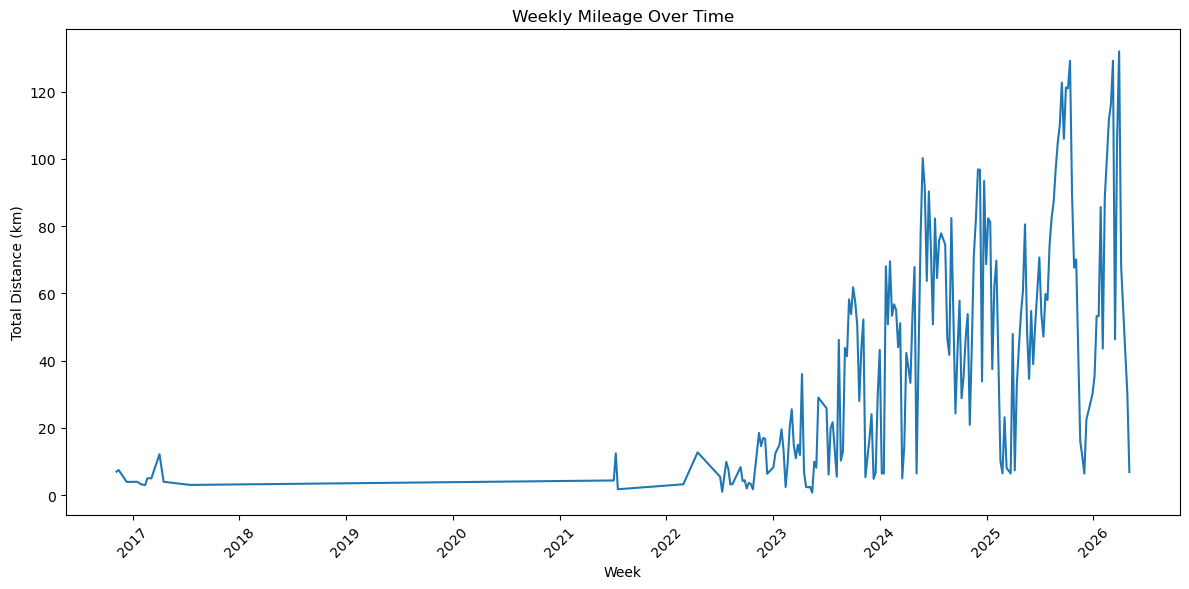

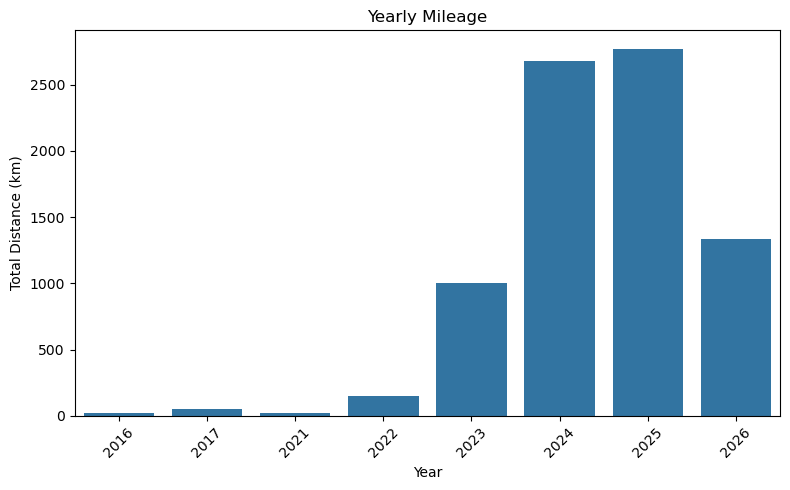

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Weekly mileage plot
runs_df['week'] = runs_df['start_time'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_mileage = runs_df.groupby('week')['distance_km'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=weekly_mileage, x='week', y='distance_km')
plt.title('Weekly Mileage Over Time')
plt.xlabel('Week')
plt.ylabel('Total Distance (km)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Yearly mileage plot
runs_df['year'] = runs_df['start_time'].dt.year
yearly_mileage = runs_df.groupby('year')['distance_km'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=yearly_mileage, x='year', y='distance_km')
plt.title('Yearly Mileage')
plt.xlabel('Year')
plt.ylabel('Total Distance (km)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

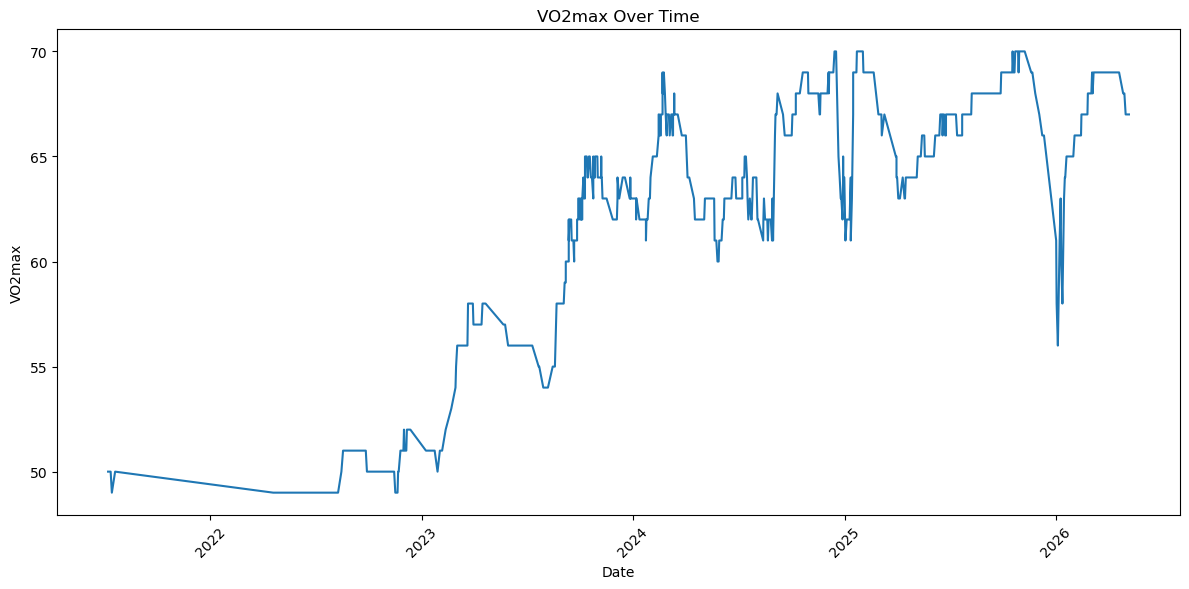

In [19]:
# V02max timeline plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=runs_df, x='start_time', y='vO2MaxValue')
plt.title('VO2max Over Time')
plt.xlabel('Date')
plt.ylabel('VO2max')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

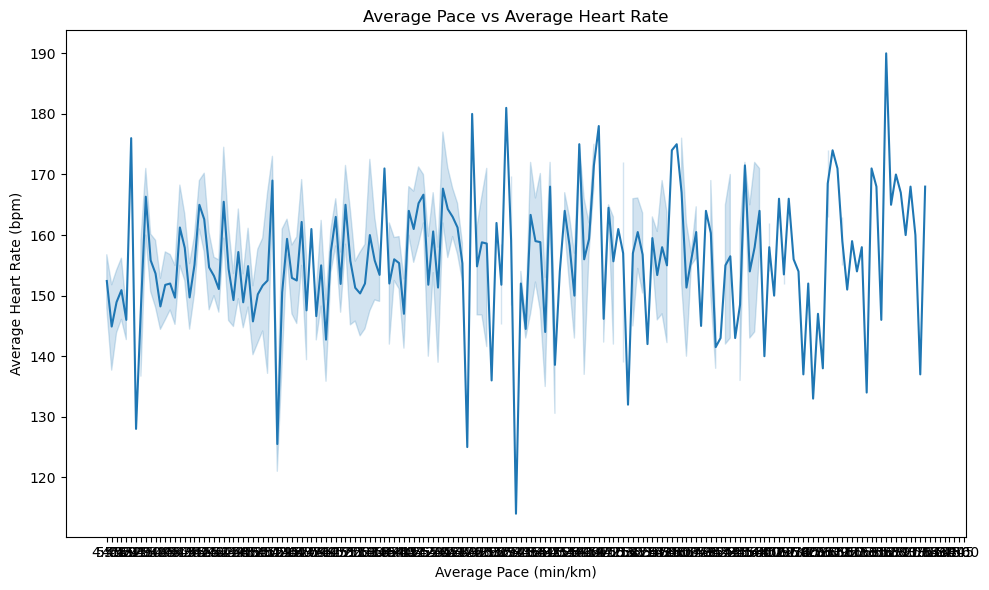

In [30]:
# Pace vs Heart Rate plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=runs_df, x='avg_pace_km', y='avgHr')
plt.title('Average Pace vs Average Heart Rate')
plt.xlabel('Average Pace (min/km)')
plt.ylabel('Average Heart Rate (bpm)')
plt.tight_layout()
plt.show()

Observe the last 4 years since this is when I began to run long distance more heavily.

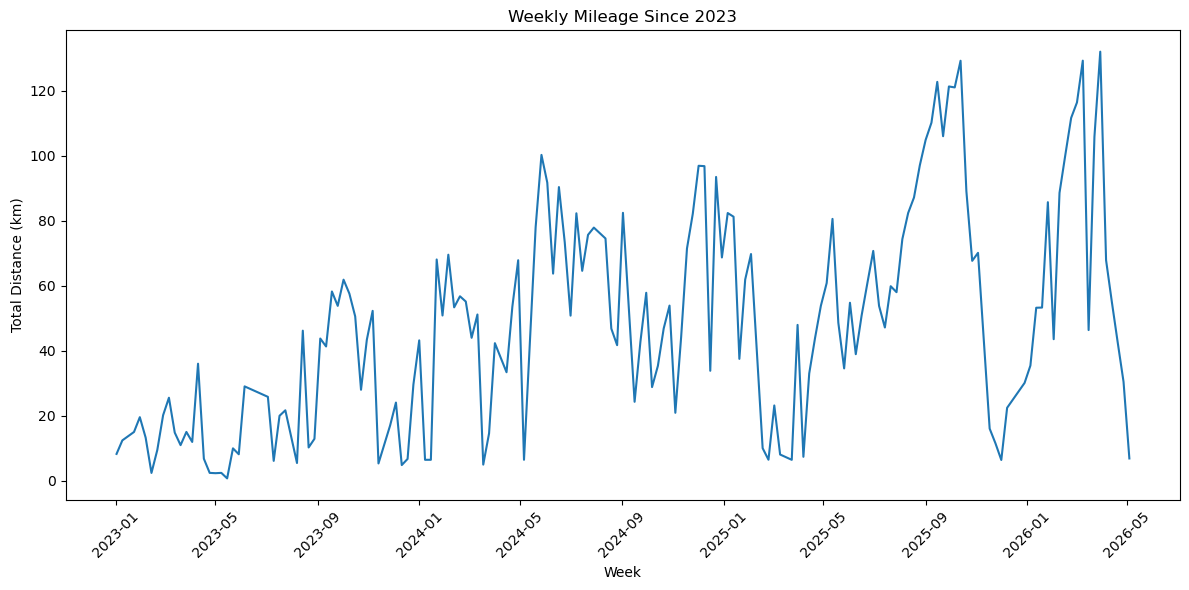

In [28]:
# Filter starting from 2023
runs_2023 = runs_df[
    runs_df['start_time'].dt.year >= 2023
].copy()

# Weekly mileage
runs_2023['week'] = (
    runs_2023['start_time']
    .dt.to_period('W')
    .apply(lambda r: r.start_time)
)

weekly_mileage = (
    runs_2023
    .groupby('week')['distance_km']
    .sum()
    .reset_index()
)

# Plot
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=weekly_mileage,
    x='week',
    y='distance_km'
)

plt.title('Weekly Mileage Since 2023')
plt.xlabel('Week')
plt.ylabel('Total Distance (km)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()